#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [1]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

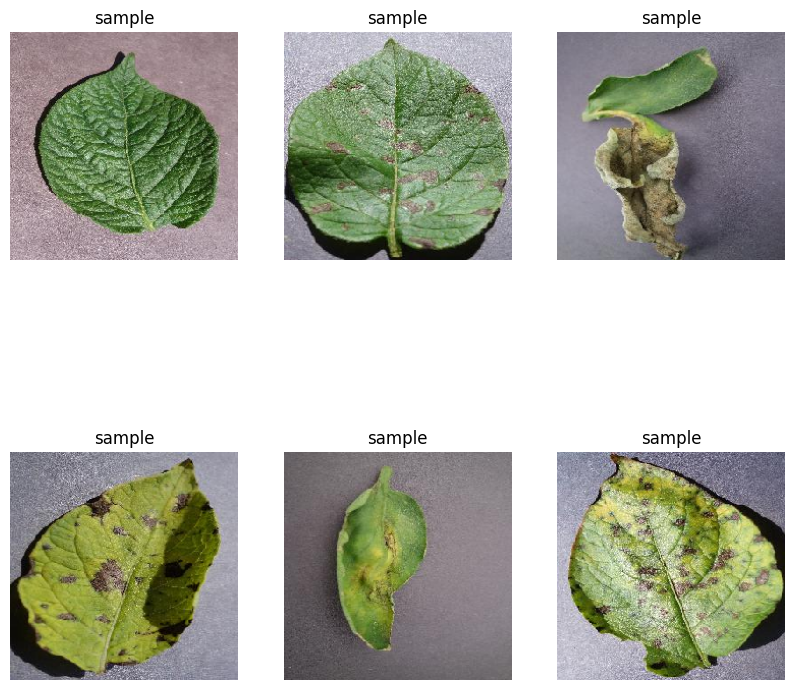

In [4]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [15]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.4850 - loss: 1.4203 - val_accuracy: 0.7333 - val_loss: 0.6981
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8883 - loss: 0.3223 - val_accuracy: 0.9400 - val_loss: 0.2286
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9650 - loss: 0.1187 - val_accuracy: 0.9467 - val_loss: 0.1657
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9717 - loss: 0.0881 - val_accuracy: 0.9133 - val_loss: 0.2586
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9817 - loss: 0.0496 - val_accuracy: 0.9533 - val_loss: 0.1399
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9933 - loss: 0.0278 - val_accuracy: 0.9600 - val_loss: 0.1547
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.9900 - loss: 0.0259 - val_accuracy: 0.9267 - val_loss: 0.3066
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9733 - loss: 0.0852 - val_accuracy: 0.9467 - val_loss:

# Plot Accuracy & Loss

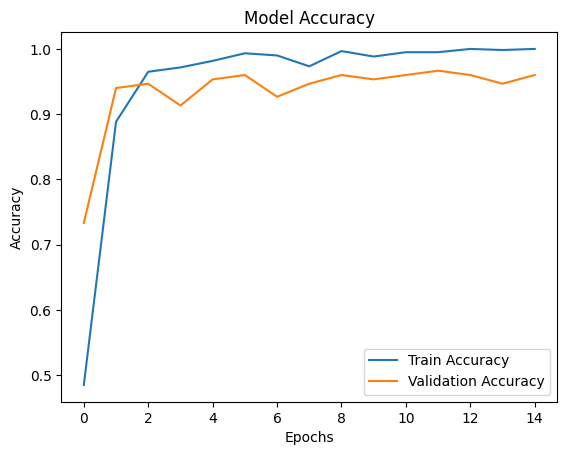

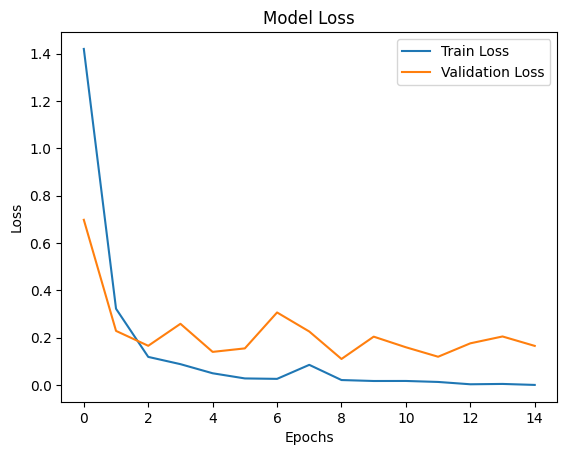

In [16]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Transfer Learning MODEL 1 - MobileNetV2
 (Before Tuning)


In [8]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8117 - loss: 0.4621 - val_accuracy: 0.9600 - val_loss: 0.0802
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9767 - loss: 0.0705 - val_accuracy: 0.9733 - val_loss: 0.0724
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9817 - loss: 0.0485 - val_accuracy: 0.9867 - val_loss: 0.0512
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9967 - loss: 0.0276 - val_accuracy: 0.9800 - val_loss: 0.0515
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9917 - loss: 0.0234 - val_accuracy: 0.9800 - val_loss: 0.0426
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9967 - loss: 0.0214 - val_accuracy: 0.9867 - val_loss: 0.0499
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9983 - loss: 0.0089 - val_accuracy: 0.9867 - val_loss: 0.0386
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 1.0000 - loss: 

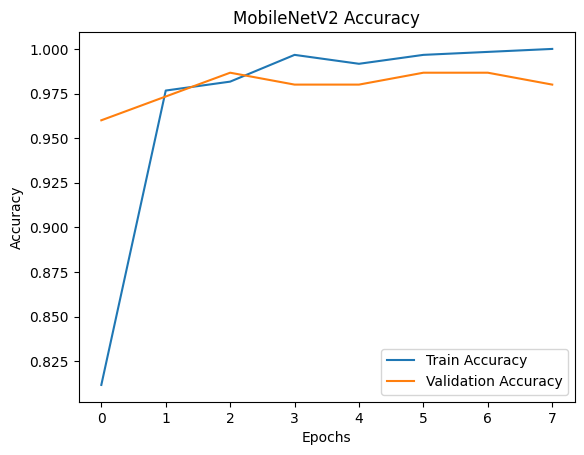

In [9]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Transfer Learning MODEL 1 - MobileNetV2

(After Tuning )

In this i just did

Tuned learning rate ( Reduce learning rate automatically)

Early stopping

In [10]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

tl_model = Model(
    inputs=base_model.input,
    outputs=output
)


tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

tl_history = tl_model.fit(
    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.3867 - loss: 1.4336 - val_accuracy: 0.8133 - val_loss: 0.7683 - learning_rate: 1.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7133 - loss: 0.7386 - val_accuracy: 0.9600 - val_loss: 0.3907 - learning_rate: 1.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9033 - loss: 0.4141 - val_accuracy: 0.9733 - val_loss: 0.2394 - learning_rate: 1.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9033 - loss: 0.3304 - val_accuracy: 0.9733 - val_loss: 0.1727 - learning_rate: 1.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9367 - loss: 0.2335 - val_accuracy: 0.9800 - val_loss: 0.1327 - learning_rate: 1.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9700 - loss: 0.1756 - val_accuracy: 0.9800 - val_loss: 0.1101 - learning_rate: 1.0000e-04
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9783 - loss:

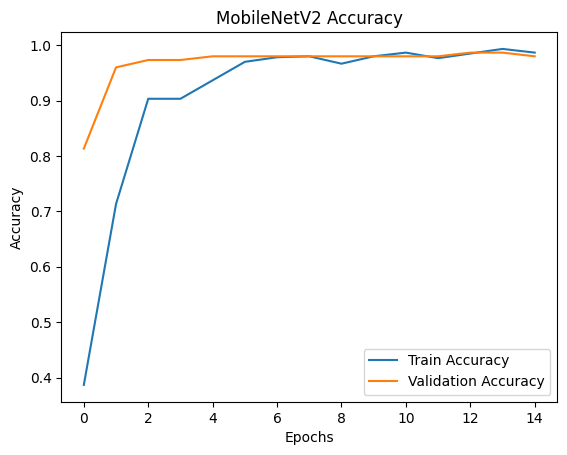

In [11]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()